# sc_inj: The LCLS-II injector

In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

In [2]:
from astra import Astra
from distgen import Generator
import os

%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
# Substitute your own LCLS_LATTICE and ATSTA paths here if needed:
# %env LCLS_LATTICE=/Users/nneveu/github/lcls-lattice
# %env ASTRA_BIN=/Users/nneveu/Code/astra/Astra

# Distgen

In [4]:
DISTGEN_IN = '$LCLS_LATTICE/distgen/models/sc_inj/v0/distgen.yaml'

G = Generator(DISTGEN_IN)
G['n_particle'] = 100_000
G

<disgten.Generator with input: 
n_particle: 100000
r_dist:
  max_r:
    units: mm
    value: 0.5
  type: radial_uniform
random_type: hammersley
start:
  MTE:
    units: meV
    value: 330
  type: cathode
t_dist:
  avg_t:
    units: ps
    value: 0
  n_sigma_cutoff: 3
  sigma_t:
    units: ps
    value: 8.5
  type: gaussian
total_charge:
  units: pC
  value: 100

>

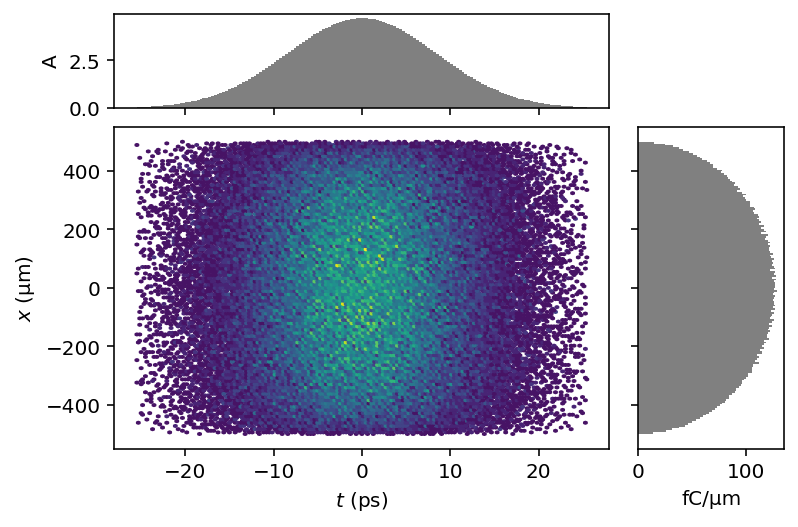

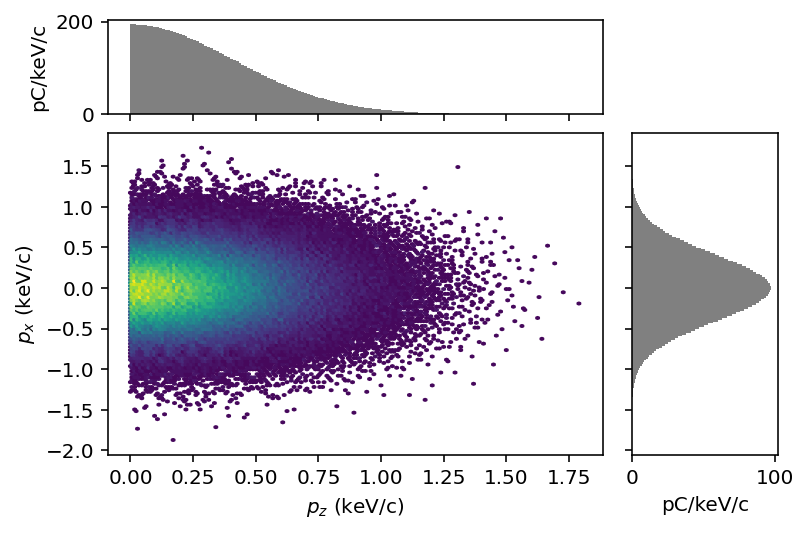

In [5]:
# Make the particles
G.run()
P0 = G.particles
P0.plot('t', 'x')
P0.plot('pz', 'px')

In [6]:
P0.status

array([0, 0, 0, ..., 0, 0, 0])

# Astra

In [7]:
ASTRA_IN = '$LCLS_LATTICE/astra/models/sc_inj/v1/astra.in'

In [8]:
A = Astra(ASTRA_IN, initial_particles=P0, verbose=True)
A.load_fieldmaps(search_paths=['../../fieldmaps/'])
#A.input['charge']['lspch'] = False

Loading fieldmap file apex_gun_z_Ez.dat
apex_gun_z_Ez.dat not found, searching:
Found: ../../fieldmaps/apex_gun_z_Ez.dat
Loading fieldmap file APEX2cellBuncher.dat
APEX2cellBuncher.dat not found, searching:
Found: ../../fieldmaps/APEX2cellBuncher.dat
Loading fieldmap file cavity9_1300MHz_z_Ez.dat
cavity9_1300MHz_z_Ez.dat not found, searching:
Found: ../../fieldmaps/cavity9_1300MHz_z_Ez.dat
Loading fieldmap file cavity9_1300MHz_z_Ez.dat
cavity9_1300MHz_z_Ez.dat not found, searching:
Found: ../../fieldmaps/cavity9_1300MHz_z_Ez.dat
Loading fieldmap file cavity9_1300MHz_z_Ez.dat
cavity9_1300MHz_z_Ez.dat not found, searching:
Found: ../../fieldmaps/cavity9_1300MHz_z_Ez.dat
Loading fieldmap file cavity9_1300MHz_z_Ez.dat
cavity9_1300MHz_z_Ez.dat not found, searching:
Found: ../../fieldmaps/cavity9_1300MHz_z_Ez.dat
Loading fieldmap file cavity9_1300MHz_z_Ez.dat
cavity9_1300MHz_z_Ez.dat not found, searching:
Found: ../../fieldmaps/cavity9_1300MHz_z_Ez.dat
Loading fieldmap file cavity9_1300MHz_z

In [9]:
#A.run()
#A.archive('v1/astra_sc_inj_v1.h5')
A.load_archive('v1/astra_sc_inj_v1.h5')

Reading group ./ from archive file v1/astra_sc_inj_v1.h5
Loaded from archive. Note: Must reconfigure to run again.


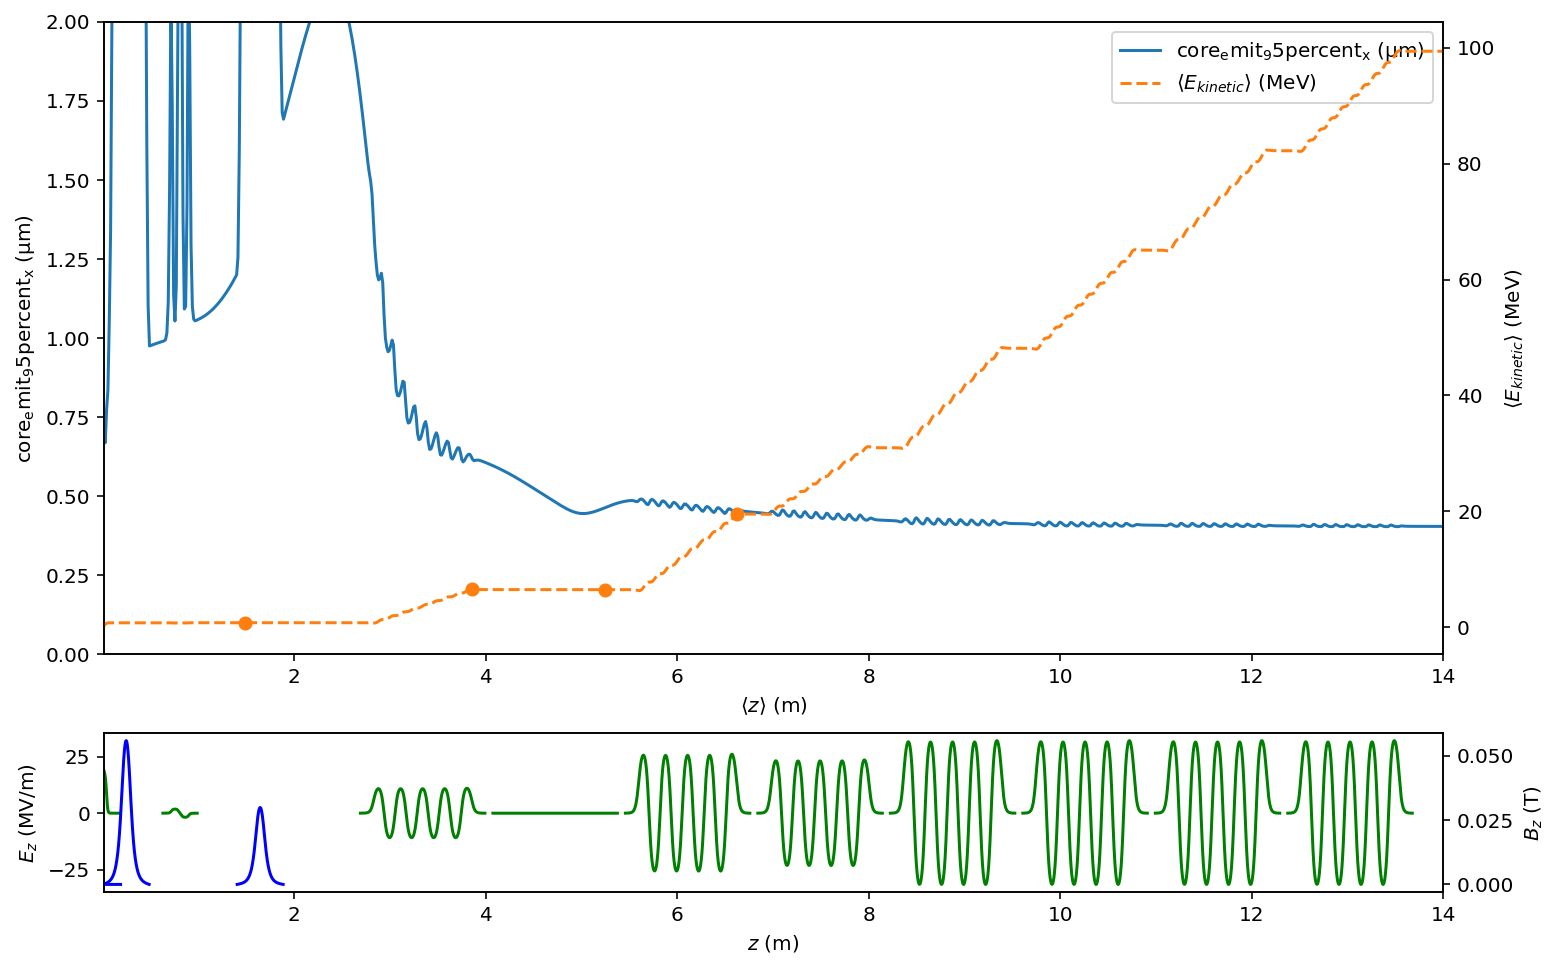

In [10]:
A.verbose=False
A.plot('core_emit_95percent_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))

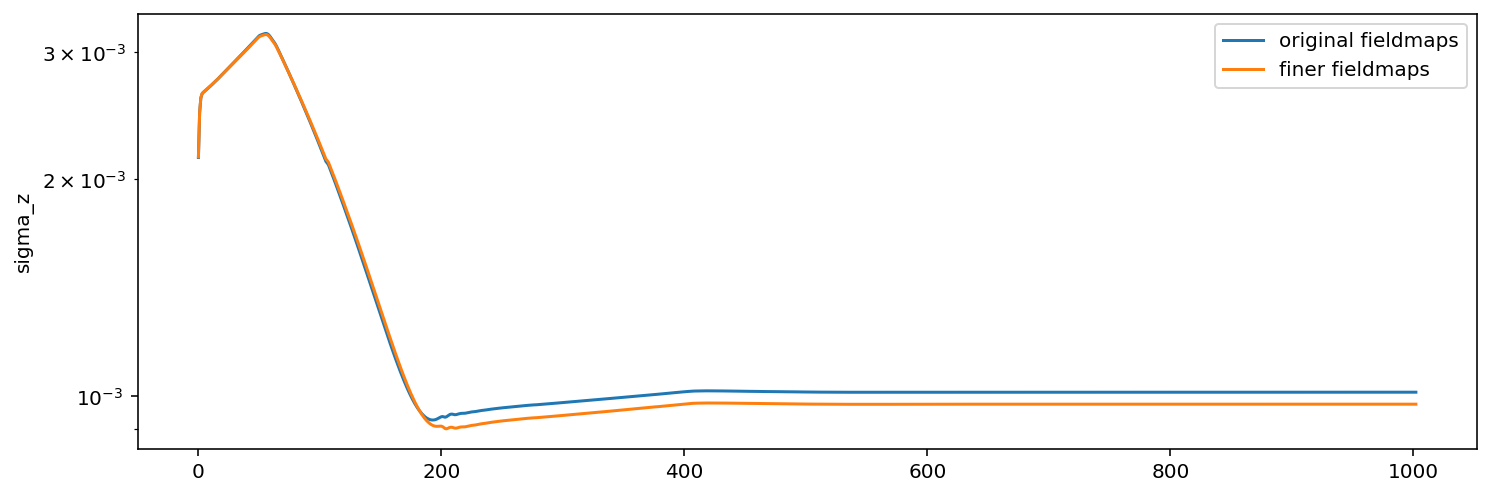

In [11]:
A0 = Astra.from_archive('v1/astra.h5')

fig, ax = plt.subplots(figsize=(12,4))
ykey = 'sigma_z'
ax.plot(A0.stat(ykey), label='original fieldmaps')
ax.plot(A.stat(ykey), label='finer fieldmaps')
ax.set_yscale('log')
ax.set_ylabel(ykey)
plt.legend()

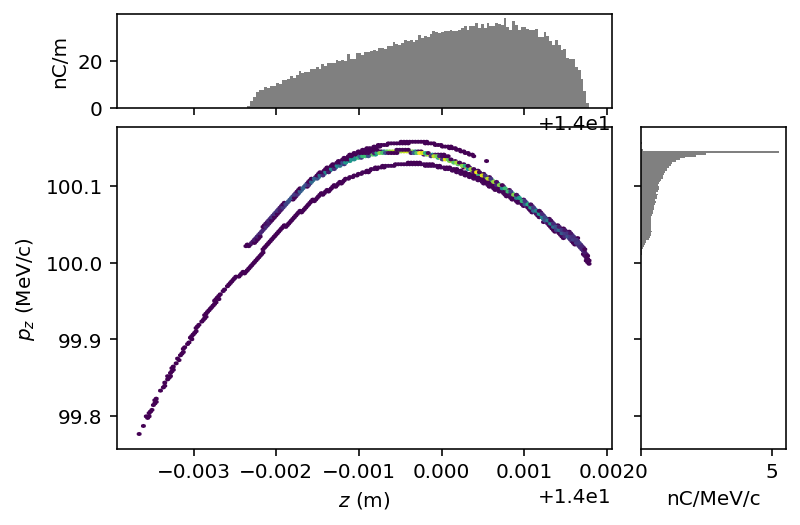

In [12]:
A0.particles[-1].plot('z', 'pz')

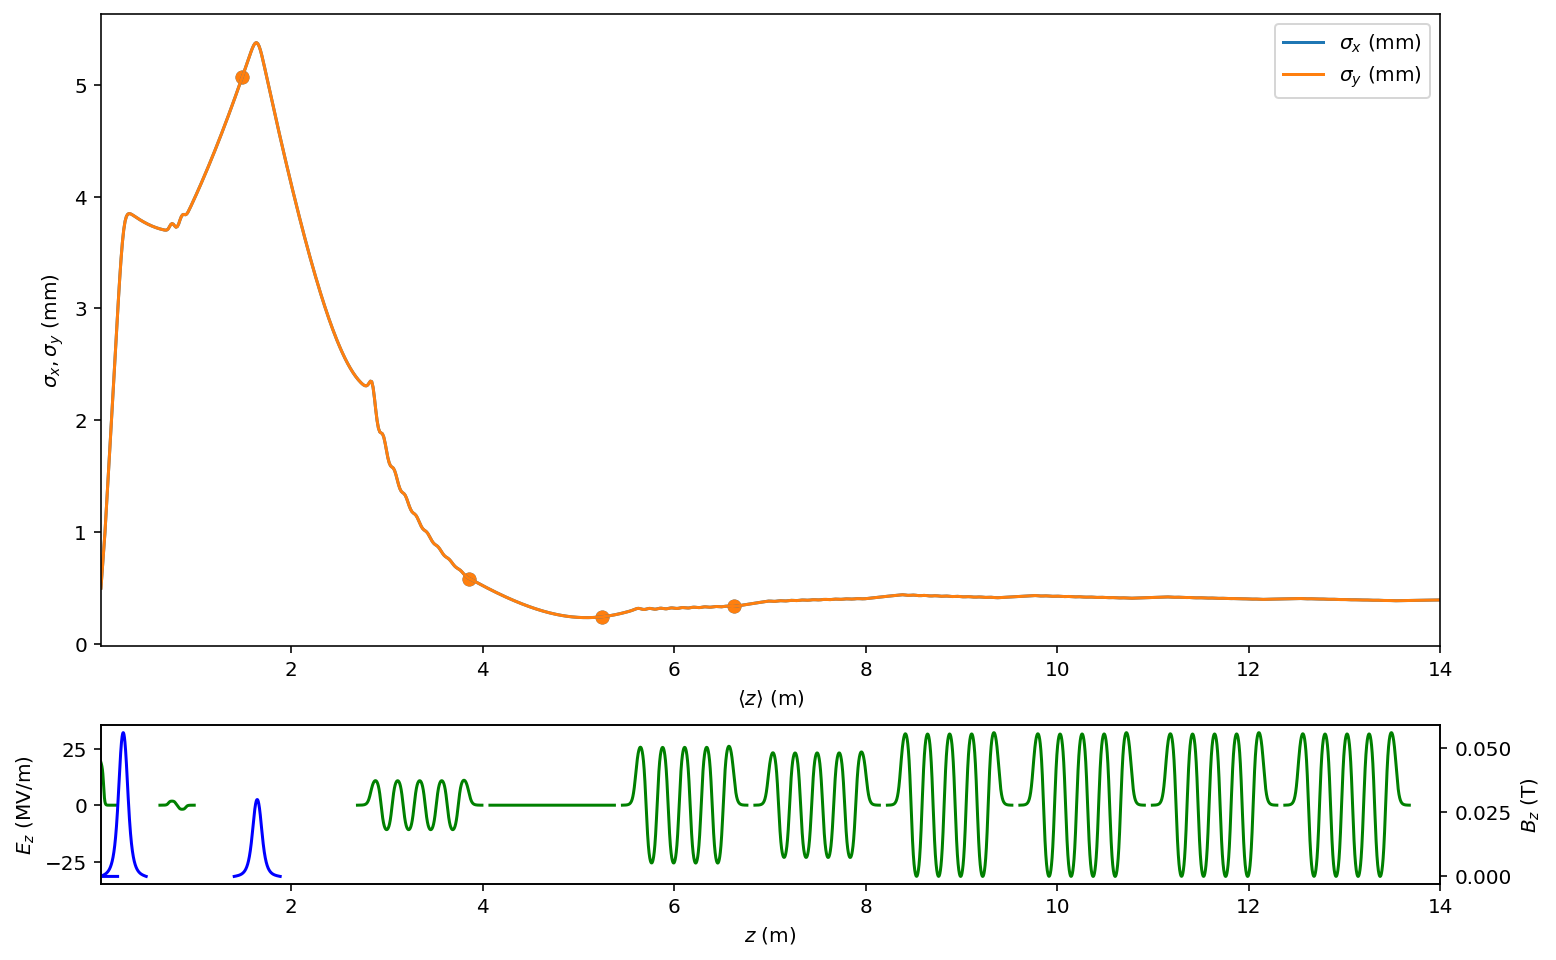

In [13]:
A.plot(['sigma_x', 'sigma_y'], figsize=(12,8))

In [14]:
# Look at final particles
Pf = A.particles[-1]
Pf.twiss('xy', 0.95)

{'alpha_x': -2.3969199761899103,
 'beta_x': 62.54765354950331,
 'gamma_x': 0.1078413815622953,
 'emit_x': 2.0854566104909105e-09,
 'eta_x': 0.00014902821723348215,
 'etap_x': -1.033578524471891e-06,
 'norm_emit_x': 4.077050082107756e-07,
 'alpha_y': -2.40083215363396,
 'beta_y': 62.62216238061563,
 'gamma_y': 0.10801279886841529,
 'emit_y': 2.086434440973229e-09,
 'eta_y': 0.0005863673402164183,
 'etap_y': 3.270077151342452e-05,
 'norm_emit_y': 4.0789605779479747e-07}

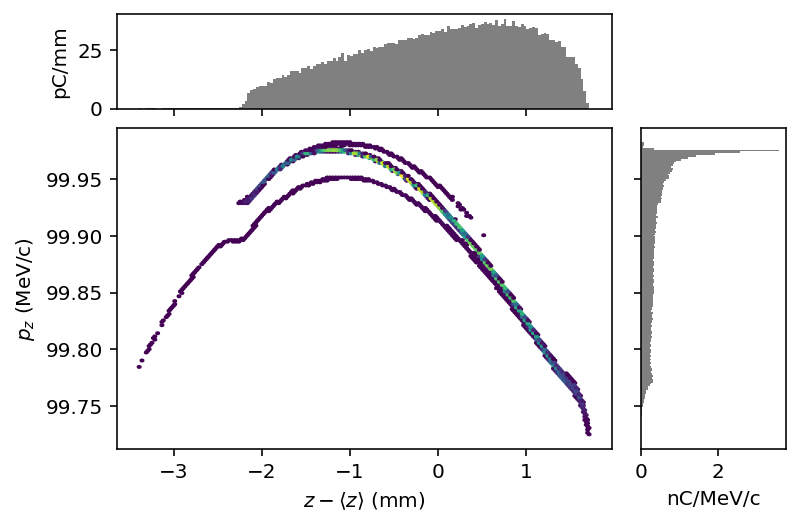

In [15]:
Pf.plot('delta_z', 'pz')

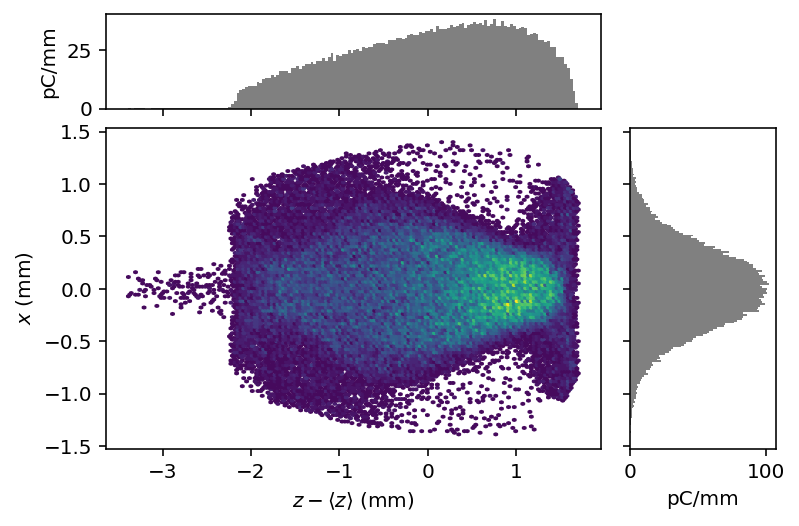

In [16]:
Pf.plot('delta_z', 'x')

In [17]:
Pf['mean_energy']

99901088.39775068

# Scan final cavity

In [18]:
from concurrent.futures import ProcessPoolExecutor

In [19]:
# Allows processes to work with macOS
from sys import platform 
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

In [20]:
def set1(phi_deg):
    
    A2 = A.copy()
    A2.verbose=False
    A2.initial_particles =  A.particles[-2]
    A2.configure()
    A2.input['charge']['lspch'] = False
    #A2.input['cavity']['maxe(6)'] = maxe6
    A2.input['cavity']['phi(9)'] = 0
    A2.input['cavity']['phi(10)'] = phi_deg
    A2.run()
    return A2.particles[-1]
    
#set1(0)    

In [21]:
xlist = np.linspace(-10, 0, 4)

In [22]:
with ProcessPoolExecutor(max_workers=4) as executor:
    results1 = list(executor.map(set1, xlist))    

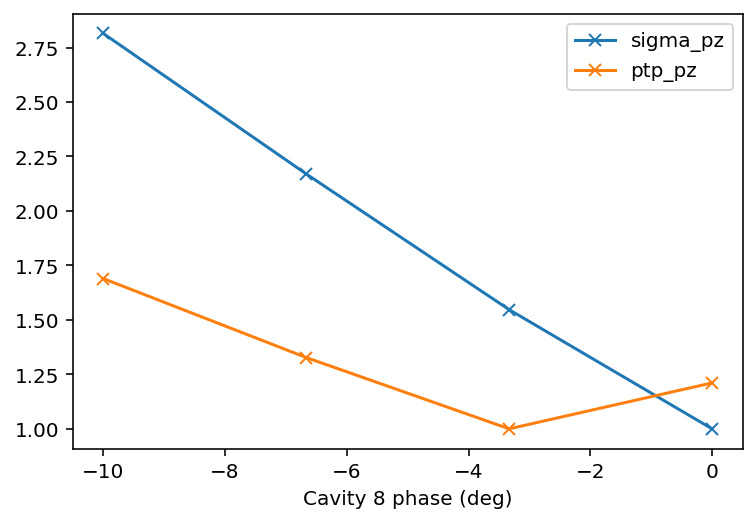

In [23]:
spz = np.array([P['sigma_pz'] for P in results1])
ptp_pz = np.array([P['ptp_pz'] for P in results1])
plt.plot(xlist, spz/spz.min(), marker='x', label='sigma_pz')
plt.plot(xlist, ptp_pz/ptp_pz.min(), marker='x', label='ptp_pz')
plt.xlabel('Cavity 8 phase (deg)')
plt.legend()

In [24]:
xlist[ptp_pz.argmin()], xlist[spz.argmin()]

(-3.333333333333333, 0.0)

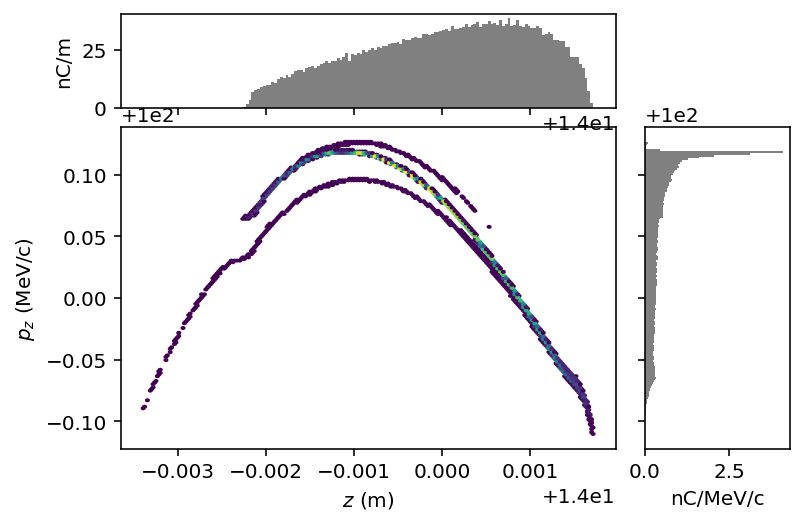

In [25]:
results1[ptp_pz.argmin()].plot('z', 'pz')

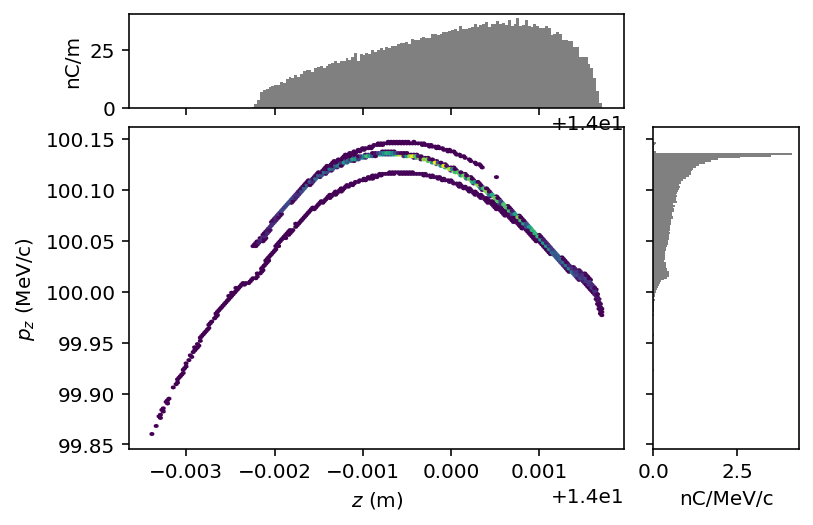

In [26]:
results1[spz.argmin()].plot('z', 'pz')

## Scan cavity 6 voltage

In [27]:
def set2(maxe6, phi_deg=-8):
    
    A2 = A.copy()
    A2.verbose=False
    A2.initial_particles =  A.particles[-2]
    A2.configure()
    A2.input['charge']['lspch'] = False
    A2.input['cavity']['maxe(6)'] = maxe6
    A2.input['cavity']['phi(9)'] = 0
    A2.input['cavity']['phi(10)'] = phi_deg
    A2.run()
    return A2.particles[-1]
    
#set1(0)    

In [28]:
%%time
xlist2 = np.linspace(21, 32, 4)

with ProcessPoolExecutor(max_workers=4) as executor:
    results2 = list(executor.map(set2, xlist2))    

CPU times: user 7.71 ms, sys: 28.2 ms, total: 36 ms
Wall time: 2min 15s


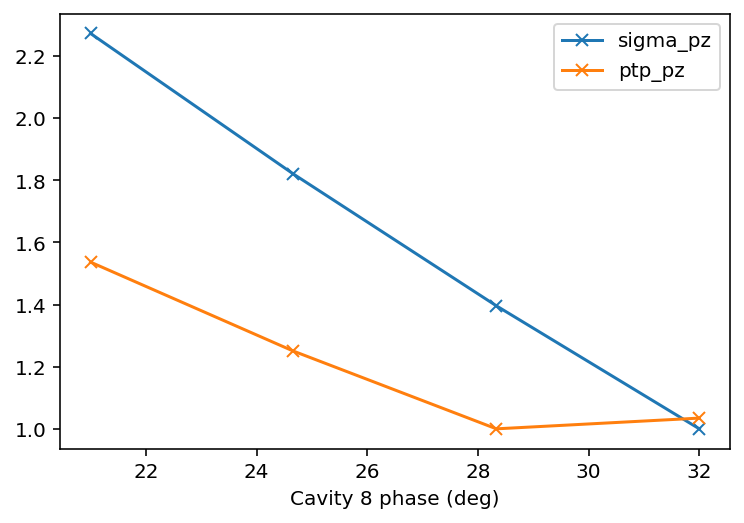

In [29]:
spz = np.array([P['sigma_pz'] for  P in results2])
ptp_pz = np.array([P['ptp_pz'] for P in results2])
plt.plot(xlist2, spz/spz.min(), marker='x', label='sigma_pz')
plt.plot(xlist2, ptp_pz/ptp_pz.min(), marker='x', label='ptp_pz')
plt.xlabel('Cavity 8 phase (deg)')
plt.legend() 

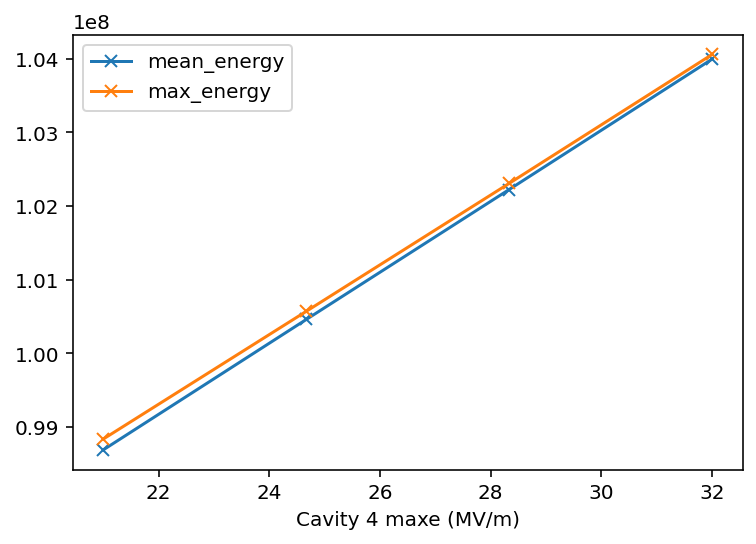

In [30]:
mean_energy = np.array([P['mean_energy'] for P in results2])
max_energy = np.array([P['max_energy'] for P in results2])
plt.plot(xlist2, mean_energy, marker='x', label='mean_energy')
plt.plot(xlist2, max_energy, marker='x', label='max_energy')
plt.xlabel('Cavity 4 maxe (MV/m)')
plt.legend()

In [31]:
m,b = np.polyfit(xlist2, mean_energy, 1)
target = 100e6
(target-b)/m #

23.714053767963946

# Visualization

Run with fewer particles

In [32]:
A = Astra(ASTRA_IN, initial_particles=P0.resample(10000))
A.load_fieldmaps(search_paths=['../../fieldmaps/'])
#A.verbose=True
A.input['charge']['nrad']= 20
A.input['charge']['nlong_in'] = 43

# Remove screens, because they conflict with zphase outpt
for k in list(A.input['output']):
    if k.startswith('screen'):
        A.input['output'].pop(k)
A.input['output']['zphase'] = 1000

In [33]:
%%time
A.run()

CPU times: user 45.2 s, sys: 1.04 s, total: 46.3 s
Wall time: 5min 13s


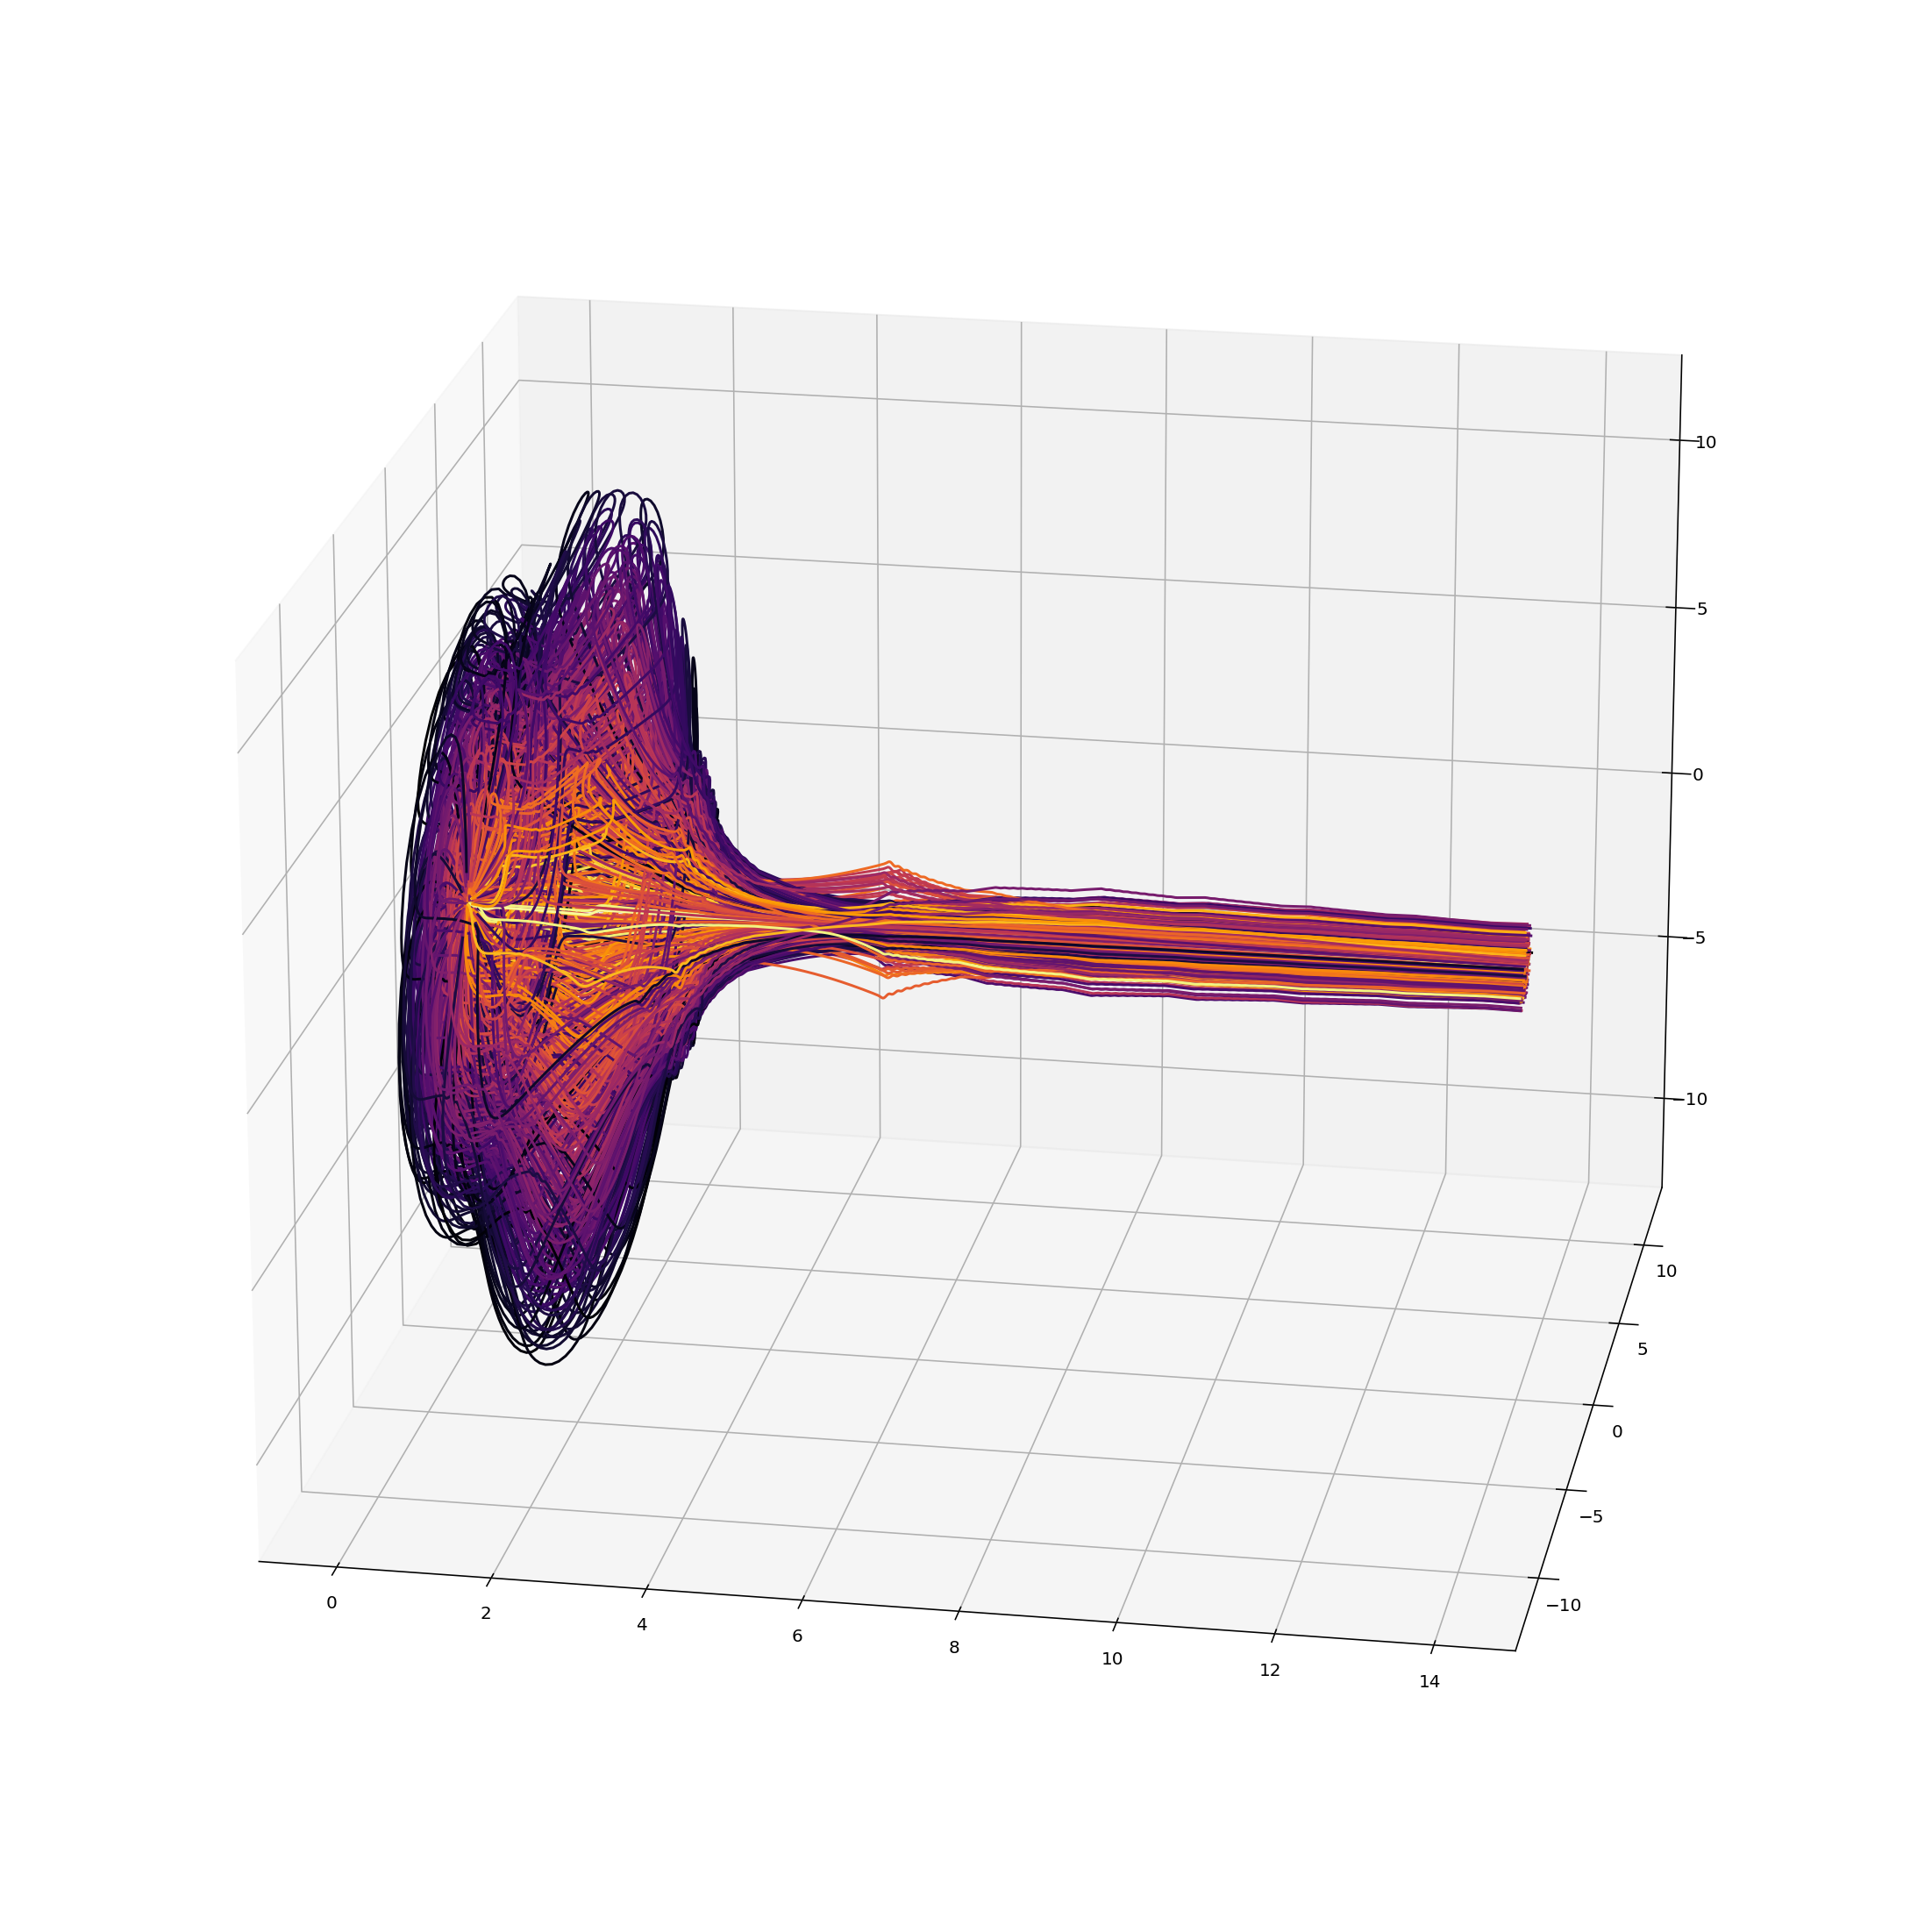

In [34]:
# 3D plot
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111, projection='3d')
cmap = matplotlib.cm.get_cmap('inferno')

skip = 10

X = np.array([P.x[::skip] for P in  A.particles]).T
Y = np.array([P.y[::skip]  for P in  A.particles]).T
Z = np.array([P.z[::skip]  for P in  A.particles]).T

scale = np.hypot(X[:, 0], Y[:,0]).max()



for i in range(len(X)):
    color = cmap(1-np.hypot(X[i,0], Y[i,0])/scale)
    ax.plot(X[i]*1000, Y[i]*1000, Z[i], zdir='x', color=color)
    
ax.view_init(20, 280)    

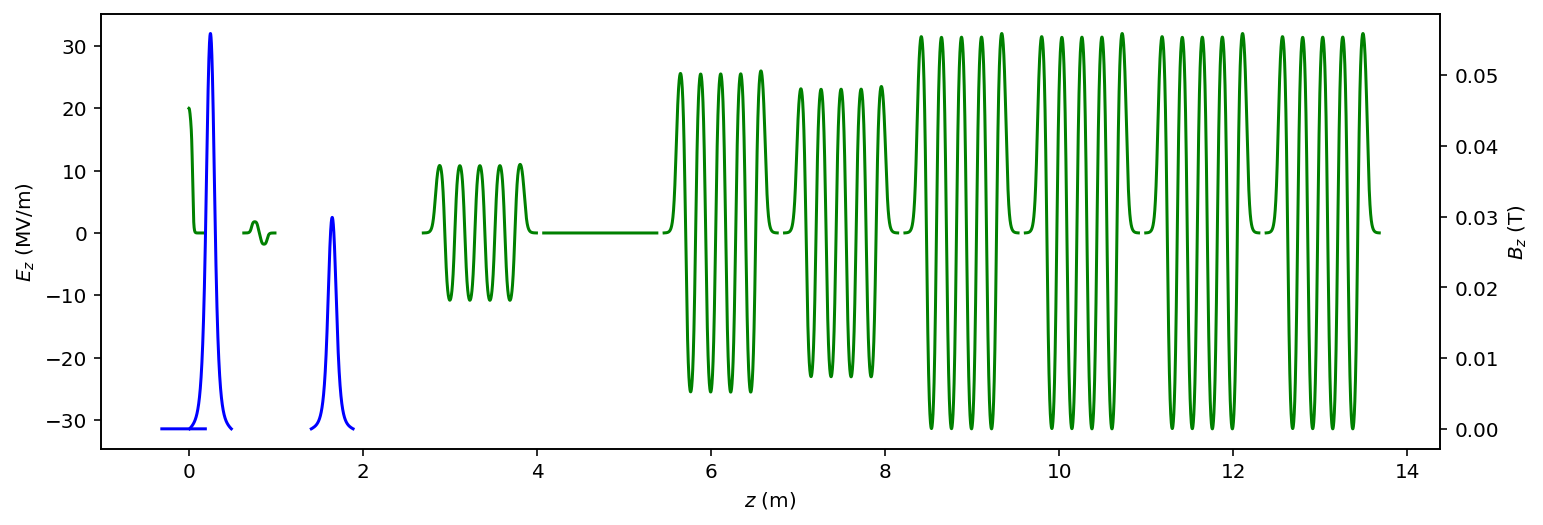

In [35]:
fig=A.plot_fieldmaps()

In [36]:
from astra.plot import add_fieldmaps_to_axes

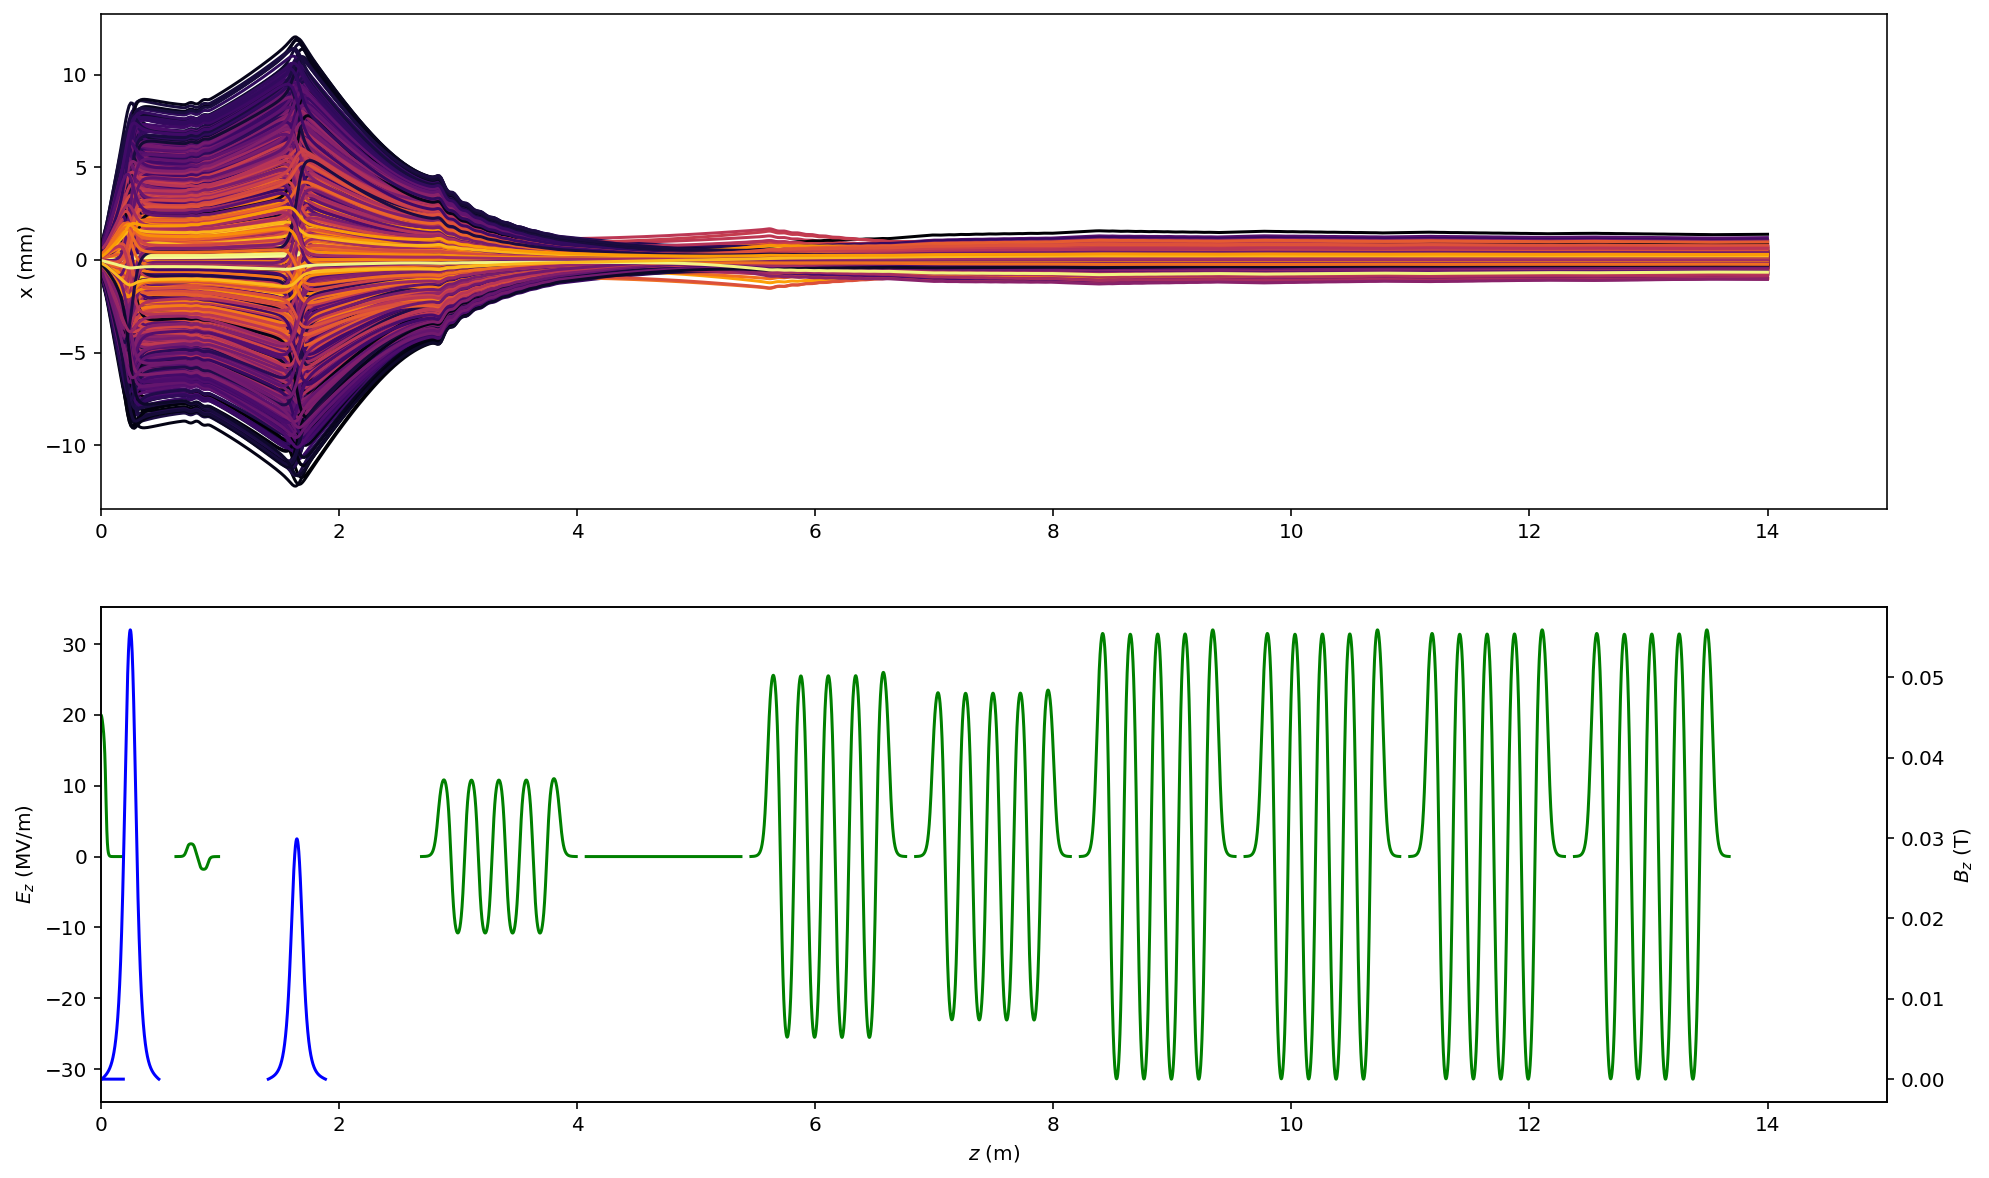

In [37]:
XLIM = (0,15)

fig, axes = plt.subplots(2, 1, figsize=(16,10))
ax = axes[0]
ax_layout = axes[1]
for i in range(len(X)):
    color = cmap(1-np.hypot(X[i,0], Y[i,0])/scale)
    ax.plot( Z[i], X[i]*1000,  color=color)
    
ax.set_ylabel('x (mm)')
ax.set_xlim(*XLIM)
add_fieldmaps_to_axes(A,  ax_layout, bounds=XLIM, include_labels=True)      